# Gradient Descent for Linear Regression

In this notebook, We will learn:

- What gradient descent is
- Why it is needed in machine learning
- How it works for linear regression
- The role of learning rate and epochs
- How loss decreases during training
- How parameters `m` and `b` get updated step by step
- How to implement gradient descent from scratch in Python

## 1. Intuition of Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the error (loss) of a model.

For linear regression, the model tries to fit a line:

\[
y = mx + b
\]

Where:
- \(m\) = slope
- \(b\) = intercept

The goal is to find the best values of \(m\) and \(b\) such that the predicted values are as close as possible to the actual values.

Gradient descent works like this:

1. Start with random or simple values of \(m\) and \(b\)
2. Compute prediction error
3. Measure in which direction the error increases
4. Move parameters in the opposite direction
5. Repeat many times until loss becomes small

It is like walking downhill on a mountain until you reach the lowest point.

## 2. Cost Function / Loss Function

To measure how bad our predictions are, we use Mean Squared Error (MSE):

### Mean Squared Error (MSE)
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Where:**
* $y_i$ = actual value
* $\hat{y}_i$ = predicted value
* $n$ = number of data points

---

### Linear Regression Model
$$\hat{y} = mx + b$$

### Cost Function ($J$)
By substituting the linear model into the MSE formula, the cost becomes:
$$J(m,b) = \frac{1}{n}\sum_{i=1}^{n}(y_i - (mx_i+b))^2$$

We want to **minimize** this cost.

## 3. Gradient of the Cost Function

Gradient descent updates parameters using partial derivatives.

### Derivative with respect to \(m\)

$$
\frac{\partial J}{\partial m} = -\frac{2}{n}\sum_{i=1}^{n} x_i(y_i - (mx_i+b))
$$

### Derivative with respect to \(b\)

$$
\frac{\partial J}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n} (y_i - (mx_i+b))
$$

### Update rule

$$
m = m - \alpha \frac{\partial J}{\partial m}
$$

$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

Where:
- $ \alpha $ = learning rate
- learning rate controls the step size

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 4. Create a simple regression dataset

In [2]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    noise=20,
    random_state=13
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 1)
Shape of y: (100,)


## Scatter plot visualization

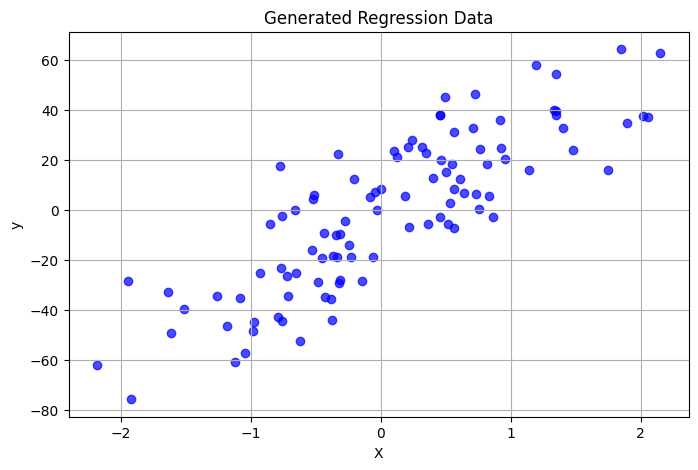

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", alpha=0.7)
plt.title("Generated Regression Data")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Train-test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

## 5. Baseline using sklearn LinearRegression
This gives us a reference to compare our gradient descent implementation.

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Sklearn slope (m):", lr.coef_[0])
print("Sklearn intercept (b):", lr.intercept_)
print("Sklearn R2 score:", r2_score(y_test, y_pred_lr))
print("Sklearn MSE:", mean_squared_error(y_test, y_pred_lr))

Sklearn slope (m): 28.125973315135614
Sklearn intercept (b): -2.2710144261783825
Sklearn R2 score: 0.6345158782661012
Sklearn MSE: 212.19806914515667


## Plot sklearn best-fit line

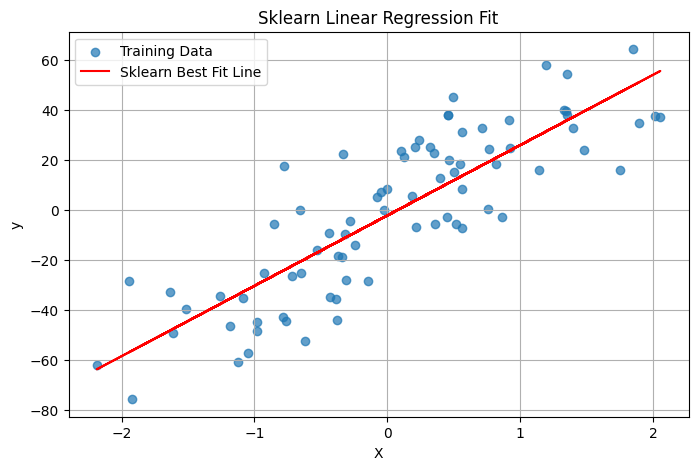

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.7, label="Training Data")
plt.plot(X_train, lr.predict(X_train), color="red", label="Sklearn Best Fit Line")
plt.title("Sklearn Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## 6. Gradient Descent from Scratch

In [7]:
class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0.0
        self.b = 0.0
        self.loss_history = []
        self.m_history = []
        self.b_history = []

    def fit(self, X, y):
        X = X.ravel()
        n = len(X)

        for epoch in range(self.epochs):
            y_pred = self.m * X + self.b

            # Compute gradients
            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            # Update parameters
            self.m = self.m - self.learning_rate * dm
            self.b = self.b - self.learning_rate * db

            # Compute loss
            loss = np.mean((y - y_pred) ** 2)

            # Store history
            self.loss_history.append(loss)
            self.m_history.append(self.m)
            self.b_history.append(self.b)

        return self

    def predict(self, X):
        X = X.ravel()
        return self.m * X + self.b

### Why `X.ravel()` is used

In libraries like **scikit-learn**, `X` (the feature matrix) usually has a 2D shape:

$$(n, 1)$$

**Example:**
If `X.shape` is $(100, 1)$, it is technically a column vector (a list of lists).

However, many mathematical operations or visualization functions become easier if we convert it to a **1D array**:

$$(n, )$$

That is why we use:

```python
X = X.ravel()

In [8]:
import numpy as np

sample = np.array([[1, 2, 3],
                   [4, 5, 6]])

print("Original shape:", sample.shape)
print(sample)

# Flatten the array
flat = sample.ravel()

print("\nFlattened shape:", flat.shape)
print(flat)

Original shape: (2, 3)
[[1 2 3]
 [4 5 6]]

Flattened shape: (6,)
[1 2 3 4 5 6]


## Train The Model

In [9]:
gd = GDRegressor(learning_rate=0.01, epochs=200)
gd.fit(X_train, y_train)

print("Learned slope (m):", gd.m)
print("Learned intercept (b):", gd.b)

Learned slope (m): 27.494282514522734
Learned intercept (b): -2.115625183624939


## Evaluate The Model

In [10]:
y_pred_gd = gd.predict(X_test)

print("Gradient Descent R2 score:", r2_score(y_test, y_pred_gd))
print("Gradient Descent MSE:", mean_squared_error(y_test, y_pred_gd))

Gradient Descent R2 score: 0.63684672539593
Gradient Descent MSE: 210.84479213253084


## Compare sklearn and Our Implementation

In [11]:
print("Sklearn m:", lr.coef_[0])
print("GD m     :", gd.m)
print()
print("Sklearn b:", lr.intercept_)
print("GD b     :", gd.b)

Sklearn m: 28.125973315135614
GD m     : 27.494282514522734

Sklearn b: -2.2710144261783825
GD b     : -2.115625183624939


## Plot The Fitted Line from Gradient Descent

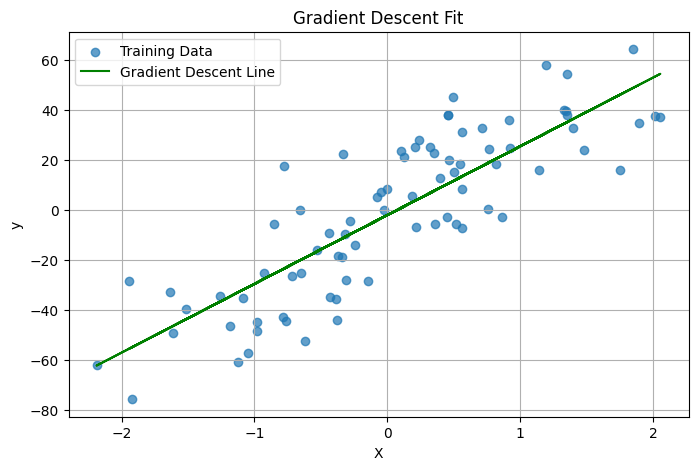

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.7, label="Training Data")
plt.plot(X_train, gd.predict(X_train), color="green", label="Gradient Descent Line")
plt.title("Gradient Descent Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## 7. Loss Curve

This plot helps us see whether gradient descent is actually learning.

If the loss decreases smoothly, training is working correctly.

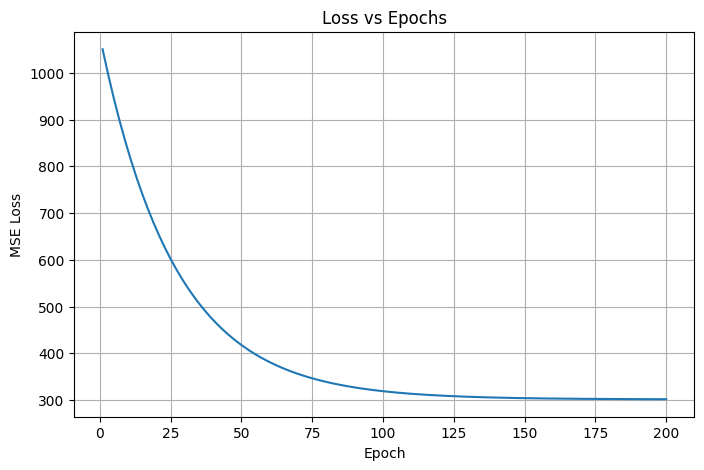

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(gd.loss_history)+1), gd.loss_history)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## Parameter Movement Plots

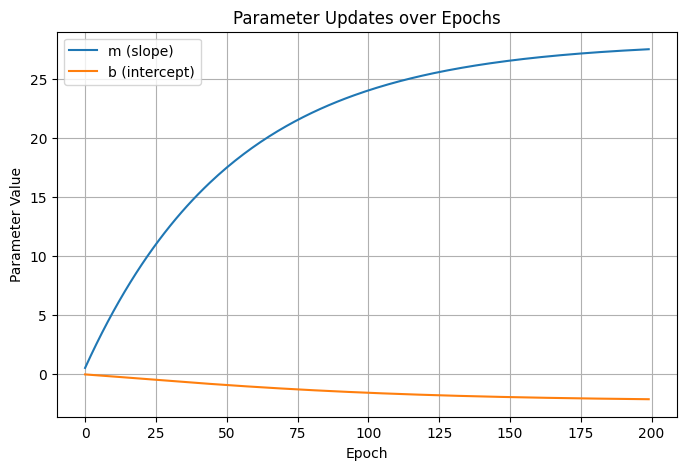

In [14]:
plt.figure(figsize=(8,5))
plt.plot(gd.m_history, label="m (slope)")
plt.plot(gd.b_history, label="b (intercept)")
plt.title("Parameter Updates over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Parameter Value")
plt.legend()
plt.grid(True)
plt.show()

## Line Evolution Visualization

This is one of the best additions for understanding.

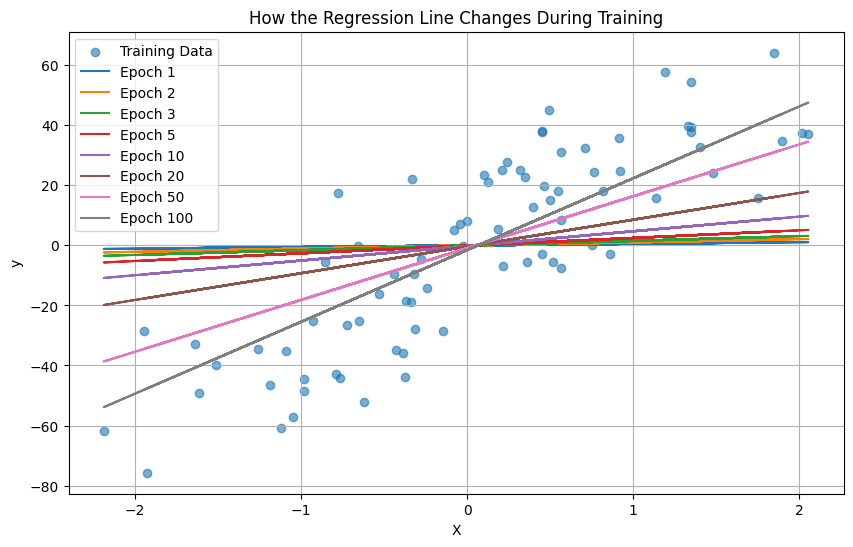

In [15]:
class GDRegressorWithSnapshots:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0.0
        self.b = 0.0
        self.loss_history = []
        self.snapshots = []

    def fit(self, X, y):
        X = X.ravel()
        n = len(X)

        for epoch in range(self.epochs):
            y_pred = self.m * X + self.b

            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            self.m -= self.learning_rate * dm
            self.b -= self.learning_rate * db

            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)

            if epoch in [0, 1, 2, 4, 9, 19, 49, 99]:
                self.snapshots.append((epoch+1, self.m, self.b))

        return self

    def predict(self, X):
        X = X.ravel()
        return self.m * X + self.b


gd_snap = GDRegressorWithSnapshots(learning_rate=0.01, epochs=100)
gd_snap.fit(X_train, y_train)


plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, alpha=0.6, label="Training Data")

for epoch, m, b in gd_snap.snapshots:
    y_line = m * X_train.ravel() + b
    plt.plot(X_train, y_line, label=f"Epoch {epoch}")

plt.title("How the Regression Line Changes During Training")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## Learning Rate Experiment

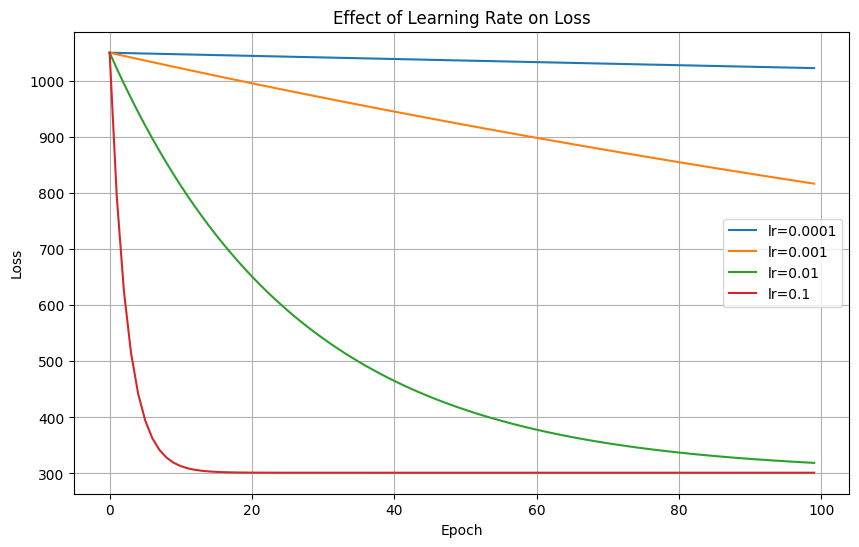

In [16]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

plt.figure(figsize=(10,6))

for lr_value in learning_rates:
    model = GDRegressor(learning_rate=lr_value, epochs=100)
    model.fit(X_train, y_train)
    plt.plot(model.loss_history, label=f"lr={lr_value}")

plt.title("Effect of Learning Rate on Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 8. Convergence

Gradient descent is said to converge when the loss keeps decreasing and finally stabilizes.

Signs of convergence:
- loss decreases over epochs
- parameter values stop changing too much
- predictions become close to actual values

Signs of bad learning:
- loss oscillates
- loss increases
- parameters become extremely large

## Final Comparison Plot

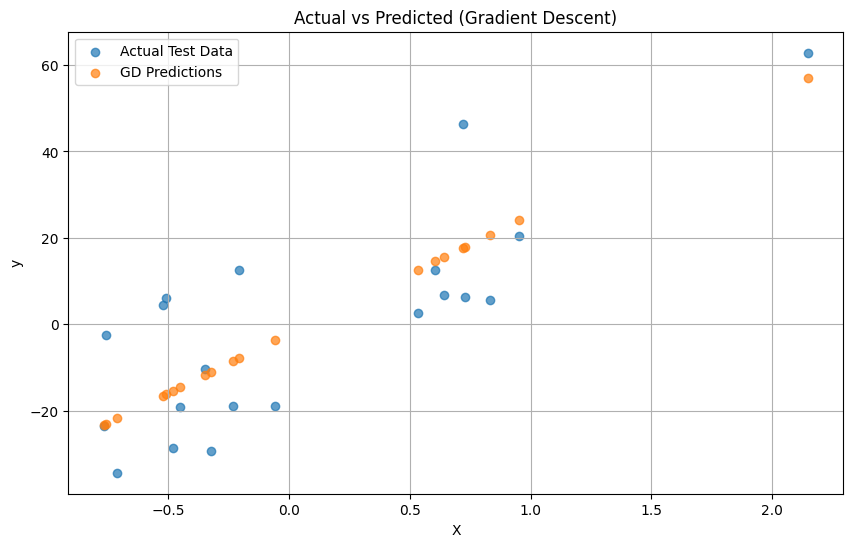

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, alpha=0.7, label="Actual Test Data")
plt.scatter(X_test, y_pred_gd, alpha=0.7, label="GD Predictions")
plt.title("Actual vs Predicted (Gradient Descent)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## 9. Summary 

In this notebook, We learned that:

- Gradient descent is used to minimize the loss function
- For linear regression, the model is \(y = mx + b\)
- MSE is commonly used as the loss function
- Gradients tell us the direction of steepest increase
- We move in the opposite direction of the gradient to reduce loss
- Learning rate decides how big each step is
- Loss curves help visualize whether the model is learning
- Gradient descent can be implemented from scratch using Python and NumPy